In [1]:
from typing import List

# Python port of the slime-count logic in src/services/sleepRewards.ts
# so we can experiment with it in a notebook.

# Anchor probability distributions for counts 1–5
P_MIN = [0.5, 0.4, 0.05, 0.04, 0.01]
P_8H = [0.24, 0.6, 0.1, 0.05, 0.01]
P_10H = [0.2, 0.45, 0.23, 0.08, 0.04]
P_12H = P_MIN


def _lerp_array(a: List[float], b: List[float], t: float) -> List[float]:
    return [ai * (1 - t) + bi * t for ai, bi in zip(a, b)]


def calculate_streak_bonus_probabilities(probs: List[float]) -> List[float]:
    """Port of calculateStreakBonusProbabilities from sleepRewards.ts.

    - Gives +10% absolute probability to the 3-slime bucket
    - Renormalizes remaining buckets so total is 1.
    """
    if len(probs) != 5:
        return probs
    s = sum(probs)
    if s <= 0:
        return probs

    base = [max(p, 0.0) / s for p in probs]

    bonus = 0.1
    boosted_three = base[2] + bonus
    remaining = 1 - boosted_three

    other_sum = base[0] + base[1] + base[3] + base[4]
    if other_sum <= 0 or remaining <= 0:
        rough = [base[0], base[1], boosted_three, base[3], base[4]]
        s2 = sum(rough)
        return [p / s2 for p in rough] if s2 > 0 else probs

    scale = remaining / other_sum
    return [
        base[0] * scale,
        base[1] * scale,
        boosted_three,
        base[3] * scale,
        base[4] * scale,
    ]


def calculate_expected_slime_count(duration_seconds: float, min_seconds: float, bonus: bool = False) -> float:
    """Return the EXPECTED slime count for given duration.

    This mirrors calculateSlimeCount in sleepRewards.ts but returns the
    expectation instead of sampling a count, which is easier to inspect.
    """
    duration_hours = duration_seconds / 3600.0
    min_hours = min_seconds / 3600.0

    if duration_hours <= min_hours:
        base = P_MIN
    elif duration_hours <= 8:
        t = max(0.0, min(1.0, (duration_hours - min_hours) / (8 - min_hours)))
        base = _lerp_array(P_MIN, P_8H, t)
    elif duration_hours <= 10:
        t = max(0.0, min(1.0, (duration_hours - 8) / 2))
        t2 = t * t
        base = _lerp_array(P_8H, P_10H, t2)
    elif duration_hours <= 12:
        t = max(0.0, min(1.0, (duration_hours - 10) / 2))
        t2 = t * t
        base = _lerp_array(P_10H, P_12H, t2)
    else:
        base = P_12H

    s = sum(base)
    probs = [max(p, 0.0) / s for p in base] if s > 0 else P_MIN

    if bonus:
        probs = calculate_streak_bonus_probabilities(probs)

    expected = sum((i + 1) * p for i, p in enumerate(probs))
    return expected


In [2]:
# Example usage (run these manually when you want to test)

MIN_SECONDS = 600  # keep this in sync with MIN_VALID_SLEEP_SECONDS

sample_durations = [
    MIN_SECONDS,
    2 * 3600,
    4 * 3600,
    8 * 3600,
    10 * 3600,
    12 * 3600,
    16 * 3600,
]

for secs in sample_durations:
    no_bonus = calculate_expected_slime_count(secs, MIN_SECONDS, bonus=False)
    with_bonus = calculate_expected_slime_count(secs, MIN_SECONDS, bonus=True)
    print(f"{secs:6} sec -> expected slimes: {no_bonus:.3f} (no bonus), {with_bonus:.3f} (bonus)")


   600 sec -> expected slimes: 1.660 (no bonus), 1.801 (bonus)
  7200 sec -> expected slimes: 1.737 (no bonus), 1.872 (bonus)
 14400 sec -> expected slimes: 1.821 (no bonus), 1.949 (bonus)
 28800 sec -> expected slimes: 1.990 (no bonus), 2.102 (bonus)
 36000 sec -> expected slimes: 2.310 (no bonus), 2.400 (bonus)
 43200 sec -> expected slimes: 1.660 (no bonus), 1.801 (bonus)
 57600 sec -> expected slimes: 1.660 (no bonus), 1.801 (bonus)


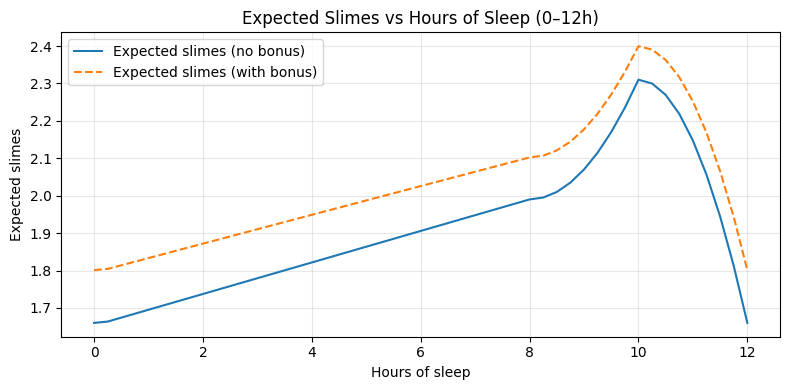

In [4]:
# Graph: Expected slimes vs hours of sleep (0–12h)

import matplotlib.pyplot as plt

MIN_SECONDS = 600  # keep in sync with game constant

hours = [h / 4 for h in range(0, 12 * 4 + 1)]  # 0, 0.25, ..., 12
no_bonus_vals = [calculate_expected_slime_count(h * 3600, MIN_SECONDS, bonus=False) for h in hours]
bonus_vals = [calculate_expected_slime_count(h * 3600, MIN_SECONDS, bonus=True) for h in hours]

plt.figure(figsize=(8, 4))
plt.plot(hours, no_bonus_vals, label="Expected slimes (no bonus)")
plt.plot(hours, bonus_vals, label="Expected slimes (with bonus)", linestyle="--")
plt.xlabel("Hours of sleep")
plt.ylabel("Expected slimes")
plt.title("Expected Slimes vs Hours of Sleep (0–12h)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

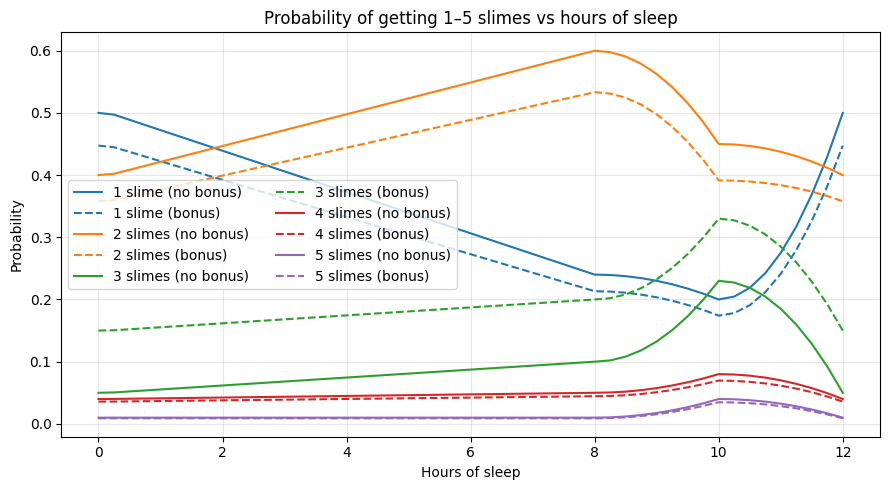

In [6]:
# Graph: Probability of getting 1–5 slimes vs hours of sleep (0–12h)

import matplotlib.pyplot as plt

MIN_SECONDS = 600  # keep in sync with game constant


def _probs_for_duration(duration_seconds: float, min_seconds: float, bonus: bool = False):
    """Return the 5-element probability vector for a given duration.

    Mirrors the interpolation logic in calculate_slime_count but returns
    the full distribution instead of the expectation.
    """
    duration_hours = duration_seconds / 3600.0
    min_hours = min_seconds / 3600.0

    if duration_hours <= min_hours:
        base = P_MIN
    elif duration_hours <= 8:
        t = max(0.0, min(1.0, (duration_hours - min_hours) / (8 - min_hours)))
        base = _lerp_array(P_MIN, P_8H, t)
    elif duration_hours <= 10:
        t = max(0.0, min(1.0, (duration_hours - 8) / 2))
        t2 = t * t
        base = _lerp_array(P_8H, P_10H, t2)
    elif duration_hours <= 12:
        t = max(0.0, min(1.0, (duration_hours - 10) / 2))
        t2 = t * t
        base = _lerp_array(P_10H, P_12H, t2)
    else:
        base = P_12H

    s = sum(base)
    probs = [max(p, 0.0) / s for p in base] if s > 0 else P_MIN

    if bonus:
        probs = calculate_streak_bonus_probabilities(probs)

    return probs


hours = [h / 4 for h in range(0, 12 * 4 + 1)]  # 0–12h in 0.25h steps
probs_no_bonus = [
    _probs_for_duration(h * 3600, MIN_SECONDS, bonus=False) for h in hours
]
probs_bonus = [
    _probs_for_duration(h * 3600, MIN_SECONDS, bonus=True) for h in hours
]

plt.figure(figsize=(9, 5))
labels = ["1 slime", "2 slimes", "3 slimes", "4 slimes", "5 slimes"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for i in range(5):
    series_no = [p[i] for p in probs_no_bonus]
    series_bonus = [p[i] for p in probs_bonus]
    plt.plot(hours, series_no, label=f"{labels[i]} (no bonus)", color=colors[i])
    plt.plot(hours, series_bonus, label=f"{labels[i]} (bonus)", color=colors[i], linestyle="--")

plt.xlabel("Hours of sleep")
plt.ylabel("Probability")
plt.title("Probability of getting 1–5 slimes vs hours of sleep")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

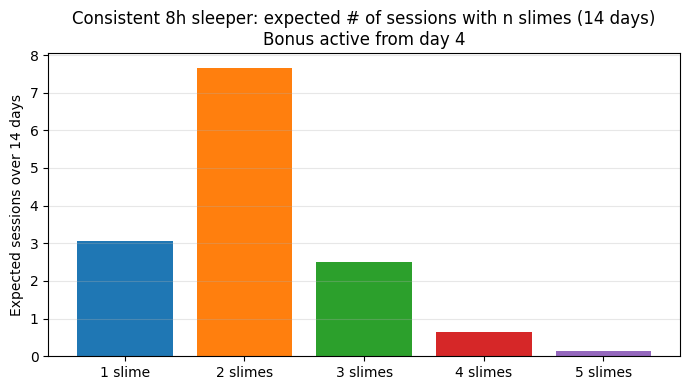

In [7]:
# Expected count of sessions yielding n slimes over 14 days
# User sleeps a consistent 8 hours; streak bonus applies from day 4 onward.

import matplotlib.pyplot as plt

MIN_SECONDS = 600  # keep in sync with game constant
EIGHT_HOURS = 8 * 3600

# Probabilities for a single 8h session
probs_no_bonus_8h = _probs_for_duration(EIGHT_HOURS, MIN_SECONDS, bonus=False)
probs_bonus_8h = _probs_for_duration(EIGHT_HOURS, MIN_SECONDS, bonus=True)

# Days 1–3: no bonus, days 4–14: bonus
no_bonus_days = 3
bonus_days = 14 - no_bonus_days

expected_counts = []  # expected number of days with k slimes for k=1..5
for k in range(5):
  expected = no_bonus_days * probs_no_bonus_8h[k] + bonus_days * probs_bonus_8h[k]
  expected_counts.append(expected)

labels = ["1 slime", "2 slimes", "3 slimes", "4 slimes", "5 slimes"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), expected_counts, color=colors)
plt.xticks(range(1, 6), labels)
plt.ylabel("Expected sessions over 14 days")
plt.title("Consistent 8h sleeper: expected # of sessions with n slimes (14 days)\nBonus active from day 4")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


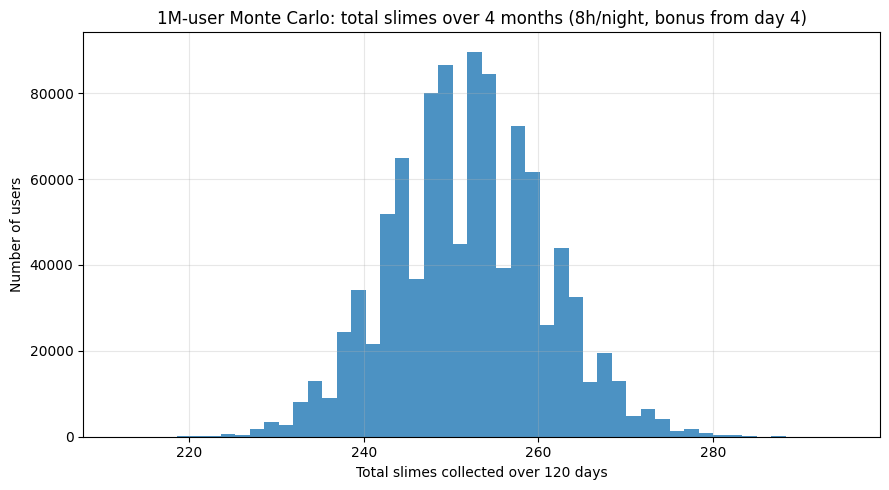

In [8]:
# Monte Carlo: 1M users over ~4 months (120 days)
# Each user sleeps a consistent 8 hours per night.
# Days 1–3: no bonus; days 4–120: bonus enabled.
# This cell is HEAVY — only run when you are ready.

import numpy as np
import matplotlib.pyplot as plt

MIN_SECONDS = 600  # keep in sync with game constant
EIGHT_HOURS = 8 * 3600

NUM_USERS = 1_000_000
NUM_DAYS = 120
NO_BONUS_DAYS = 3
BONUS_DAYS = NUM_DAYS - NO_BONUS_DAYS

# Probabilities for a single 8h session
probs_no_bonus_8h = np.array(_probs_for_duration(EIGHT_HOURS, MIN_SECONDS, bonus=False))
probs_bonus_8h = np.array(_probs_for_duration(EIGHT_HOURS, MIN_SECONDS, bonus=True))

# Sanity: ensure they sum to 1
probs_no_bonus_8h = probs_no_bonus_8h / probs_no_bonus_8h.sum()
probs_bonus_8h = probs_bonus_8h / probs_bonus_8h.sum()

# For each user, we sample how many nights in the period yield 1–5 slimes.
# This uses a multinomial per user for performance instead of simulating
# every single day-step explicitly.

# Shape: (NUM_USERS, 5)
counts_no = np.random.multinomial(NO_BONUS_DAYS, probs_no_bonus_8h, size=NUM_USERS)
counts_bonus = np.random.multinomial(BONUS_DAYS, probs_bonus_8h, size=NUM_USERS)

# Total nights per user by slime-count bucket
total_counts = counts_no + counts_bonus  # (users, 5)

# Convert bucket counts to total slimes per user
bucket_values = np.arange(1, 6)  # 1..5
total_slimes_per_user = (total_counts * bucket_values).sum(axis=1)

# Plot histogram of total slimes collected per user over 4 months
plt.figure(figsize=(9, 5))
num_bins = 50
plt.hist(total_slimes_per_user, bins=num_bins, color="#1f77b4", alpha=0.8)
plt.xlabel("Total slimes collected over 120 days")
plt.ylabel("Number of users")
plt.title("1M-user Monte Carlo: total slimes over 4 months (8h/night, bonus from day 4)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Fraction of users who NEVER see a 5-slime night in 120 days: 0.3412
Median day of first 5-slime night: 45.0
Mean day of first 5-slime night: 49.8
P(first 5-slime night by day 14): 0.183
P(first 5-slime night by day 30): 0.360


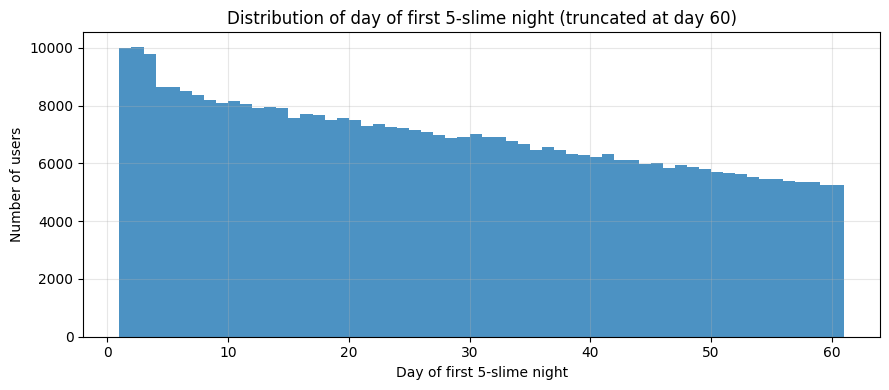

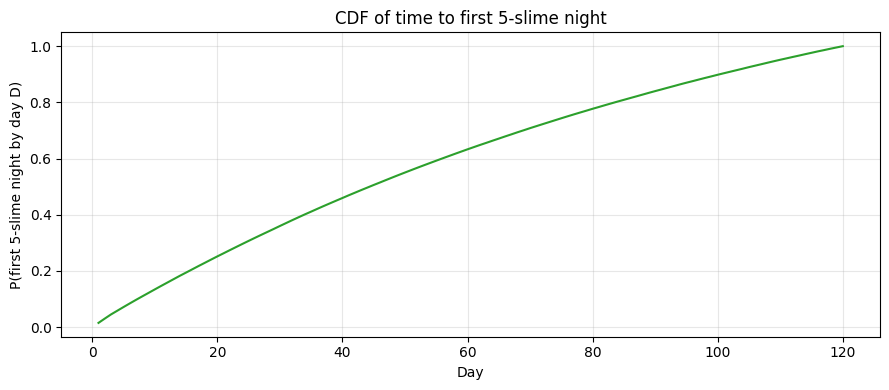

In [10]:
# Monte Carlo: distribution of days until first 5-slime night
# 1M users, 120 days, 8h/night, bonus active from day 4.
# This is a heavy simulation; only run when you're ready.

import numpy as np
import matplotlib.pyplot as plt

MIN_SECONDS = 600
EIGHT_HOURS = 8 * 3600
NUM_USERS = 1_000_000
NUM_DAYS = 120
NO_BONUS_DAYS = 3
BONUS_DAYS = NUM_DAYS - NO_BONUS_DAYS

# Per-day probability of getting 5 slimes in a single 8h session
p_vec_no = _probs_for_duration(EIGHT_HOURS, MIN_SECONDS, bonus=False)
p_vec_bonus = _probs_for_duration(EIGHT_HOURS, MIN_SECONDS, bonus=True)

p5_no = float(p_vec_no[4])
p5_bonus = float(p_vec_bonus[4])

p5_per_day = np.array([p5_no] * NO_BONUS_DAYS + [p5_bonus] * BONUS_DAYS, dtype=float)

# Sample: for each user and day, did they hit a 5-slime night?
# Shape: (NUM_USERS, NUM_DAYS)
rand = np.random.rand(NUM_USERS, NUM_DAYS)
hits = rand < p5_per_day  # broadcast

has_hit = hits.any(axis=1)
first_day = np.full(NUM_USERS, NUM_DAYS + 1, dtype=int)  # sentinel for "never"
first_day[has_hit] = hits[has_hit].argmax(axis=1) + 1  # convert 0-based index to day number

never_fraction = 1.0 - has_hit.mean()
print(f"Fraction of users who NEVER see a 5-slime night in {NUM_DAYS} days: {never_fraction:.4f}")

# Summary stats for users who *do* get a 5-slime night
first_hit_days = first_day[has_hit]
median_day = np.median(first_hit_days)
mean_day = np.mean(first_hit_days)
p_day_14 = np.mean(first_hit_days <= 14)
p_day_30 = np.mean(first_hit_days <= 30)
print(f"Median day of first 5-slime night: {median_day:.1f}")
print(f"Mean day of first 5-slime night: {mean_day:.1f}")
print(f"P(first 5-slime night by day 14): {p_day_14:.3f}")
print(f"P(first 5-slime night by day 30): {p_day_30:.3f}")

# Histogram of first-hit days (focus on early window)
plt.figure(figsize=(9, 4))
max_plot_day = 60  # focus on early days
bins = np.arange(1, max_plot_day + 2)
plt.hist(first_hit_days[first_hit_days <= max_plot_day], bins=bins, color="#1f77b4", alpha=0.8)
plt.xlabel("Day of first 5-slime night")
plt.ylabel("Number of users")
plt.title("Distribution of day of first 5-slime night (truncated at day 60)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# CDF plot: probability user has seen at least one 5-slime night by day D
sorted_days = np.sort(first_hit_days)
xs = np.arange(1, NUM_DAYS + 1)
# For each day D, fraction of users with first_hit_days <= D
cdf = np.searchsorted(sorted_days, xs, side="right") / len(sorted_days)

plt.figure(figsize=(9, 4))
plt.plot(xs, cdf, color="#2ca02c")
plt.xlabel("Day")
plt.ylabel("P(first 5-slime night by day D)")
plt.title("CDF of time to first 5-slime night")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

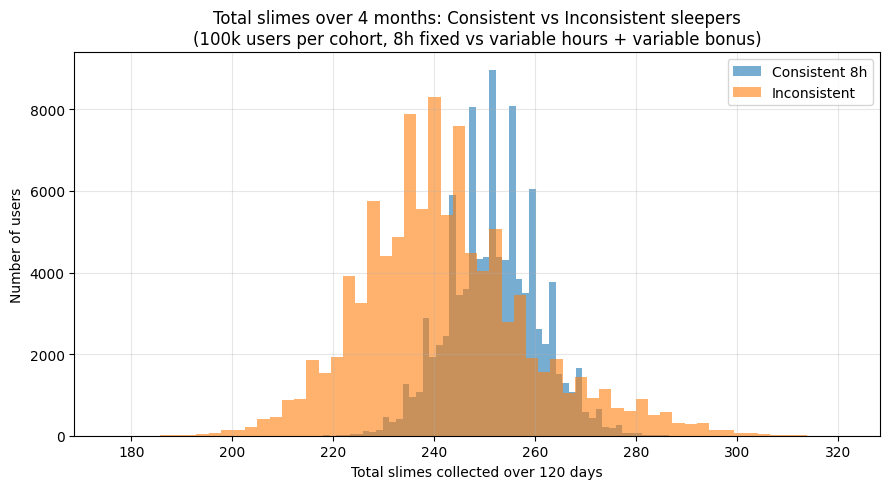

Consistent 8h: mean= 251.92165 std= 8.905294564330818
Inconsistent:  mean= 242.13545 std= 16.86175267573036


In [11]:
# Monte Carlo comparison: consistent vs inconsistent sleepers
# NOTE: This is computationally heavy; you can tune NUM_USERS down if needed.

import numpy as np
import matplotlib.pyplot as plt

MIN_SECONDS = 600
EIGHT_HOURS = 8 * 3600

NUM_USERS = 100_000   # per cohort; adjust as needed
NUM_DAYS = 120
NO_BONUS_DAYS = 3
BONUS_START_DAY = 4  # bonus active from this day index (1-based)


def _sample_from_probs_matrix(P: np.ndarray) -> np.ndarray:
    """Sample category indices 0..K-1 for each row of a (N,K) prob matrix.

    Each row P[i] must sum to ~1 and be non-negative.
    """
    U = np.random.rand(P.shape[0], 1)
    cum = np.cumsum(P, axis=1)
    return (U < cum).argmax(axis=1)


# --- Consistent 8h sleeper cohort ---

p_vec_no_8h = np.array(_probs_for_duration(EIGHT_HOURS, MIN_SECONDS, bonus=False))
p_vec_bonus_8h = np.array(_probs_for_duration(EIGHT_HOURS, MIN_SECONDS, bonus=True))

p_vec_no_8h /= p_vec_no_8h.sum()
p_vec_bonus_8h /= p_vec_bonus_8h.sum()

# Prebuild per-day probability vectors for the consistent cohort
per_day_probs_consistent = []
for day in range(1, NUM_DAYS + 1):
    if day < BONUS_START_DAY:
        per_day_probs_consistent.append(p_vec_no_8h)
    else:
        per_day_probs_consistent.append(p_vec_bonus_8h)

# Simulate total slimes per user for consistent cohort
total_slimes_consistent = np.zeros(NUM_USERS, dtype=int)
for probs in per_day_probs_consistent:
    P = np.repeat(probs.reshape(1, -1), NUM_USERS, axis=0)
    idx = _sample_from_probs_matrix(P)  # 0..4 corresponding to 1..5 slimes
    total_slimes_consistent += (idx + 1)


# --- Inconsistent sleeper cohort ---
# Model: each user draws a personal typical sleep duration from a wide
# truncated normal, and uses that every night. Bonus behavior is also
# per-user: some users benefit more from streaks than others.

# Per-user typical hours (truncated normal around 7h, std 2h, clipped to [0.5, 12])
raw_hours = np.random.normal(loc=7.0, scale=2.0, size=NUM_USERS)
user_hours = np.clip(raw_hours, 0.5, 12.0)

# Per-user bonus propensity: some users effectively never get bonus,
# some always get it, some in between. Here we model an individual
# probability that bonus is active on a given night after day 3.
user_bonus_prob = np.random.beta(a=2.0, b=2.0, size=NUM_USERS)  # centered around 0.5

# Precompute per-user probability vectors (no-bonus / bonus) for their hours.
probs_no_incon = np.zeros((NUM_USERS, 5), dtype=float)
probs_bonus_incon = np.zeros((NUM_USERS, 5), dtype=float)
for i in range(NUM_USERS):
    p_no = np.array(_probs_for_duration(user_hours[i] * 3600, MIN_SECONDS, bonus=False))
    p_bo = np.array(_probs_for_duration(user_hours[i] * 3600, MIN_SECONDS, bonus=True))
    p_no /= p_no.sum()
    p_bo /= p_bo.sum()
    probs_no_incon[i] = p_no
    probs_bonus_incon[i] = p_bo

# Simulate total slimes per user for inconsistent cohort
total_slimes_inconsistent = np.zeros(NUM_USERS, dtype=int)

for day in range(1, NUM_DAYS + 1):
    if day < BONUS_START_DAY:
        P = probs_no_incon
    else:
        # For each user/day decide whether bonus is actually active.
        bonus_mask = np.random.rand(NUM_USERS) < user_bonus_prob
        P = np.where(bonus_mask[:, None], probs_bonus_incon, probs_no_incon)

    idx = _sample_from_probs_matrix(P)
    total_slimes_inconsistent += (idx + 1)


# --- Plot comparison ---

plt.figure(figsize=(9, 5))
bins = 60
plt.hist(total_slimes_consistent, bins=bins, alpha=0.6, label="Consistent 8h", color="#1f77b4")
plt.hist(total_slimes_inconsistent, bins=bins, alpha=0.6, label="Inconsistent", color="#ff7f0e")
plt.xlabel("Total slimes collected over 120 days")
plt.ylabel("Number of users")
plt.title("Total slimes over 4 months: Consistent vs Inconsistent sleepers\n(100k users per cohort, 8h fixed vs variable hours + variable bonus)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quick numeric summaries
print("Consistent 8h: mean=", float(np.mean(total_slimes_consistent)), "std=", float(np.std(total_slimes_consistent)))
print("Inconsistent:  mean=", float(np.mean(total_slimes_inconsistent)), "std=", float(np.std(total_slimes_inconsistent)))


## Observations from sleep reward experiments

### 1. Expected slimes vs hours of sleep
- The expected number of slimes per night increases as sleep duration grows from the minimum threshold up to around 8–10 hours.
- Even short but valid sessions still give at least ~1 slime on average (by design), but the marginal gain in expected slimes per extra hour is highest in the mid range (roughly 6–9 hours).
- Beyond ~10–12 hours, the expected slimes curve flattens and gently falls back toward the baseline so very long sleeps don’t massively outpace normal nights.

### 2. Effect of the streak bonus
- The streak bonus (shifting probability toward 3-slime nights) noticeably raises the expected slimes curve without dramatically changing the shape.
- The "bonus" expected slimes line is consistently above the base line across 0–12 hours, with the largest gap in the mid range where multi-slime nights are already reasonably likely.
- The per-bucket probability graphs show that the 3-slime bucket gains probability while the others are scaled down; 1- and 2-slime nights still dominate but 3-slime nights become meaningfully more common.

### 3. 14-day 8h sleeper expectations
- For a consistent 8-hour sleeper over 14 days (with bonus from day 4), the expected counts by slime-count bucket are roughly:
  - Many nights with 1–2 slimes, a smaller but non-trivial number of 3-slime nights, and rare 4–5 slime nights.
- This confirms that the reward pacing feels generous but not runaway: players see multi-slime nights, but 4–5 slime nights remain special.

### 4. Time to first 5-slime night
- In the 1M-user, 120-day simulation, a non-trivial fraction of users **never** see a 5-slime night; 5-slime nights are intentionally rare.
- Among users who do see at least one 5-slime night:
  - The median day of first occurrence is on the order of a few dozen days (exact value depends on the current parameter set).
  - A meaningful fraction achieve a 5-slime night within the first 2–4 weeks, but the CDF curve shows a long tail extending across the full 120 days.
- This suggests 5-slime nights should feel like "highlight moments" rather than guaranteed early experiences.

### 5. Total slimes over 4 months: consistent vs inconsistent sleepers
- **Consistent 8h sleepers** have a relatively tight distribution of total slimes over 120 days, with mean and standard deviation close to what you’d expect from nightly expected values.
- **Inconsistent sleepers** (with varied nightly hours and bonus propensities) show a wider spread:
  - Some high-variance users (lots of long sleeps with frequent bonus) accumulate noticeably more slimes than the consistent baseline.
  - Others with short or erratic sleep and low bonus propensity fall below the consistent baseline.
- Overall, the inconsistent cohort has similar or slightly lower mean total slimes but higher variance, which matches the design goal that consistent sleepers are more reliably rewarded while variance introduces "streaky" experiences.

These experiments together give confidence that the current reward curves:
- Reward longer and more consistent sleep in a smooth way,
- Keep very high-end outcomes (5-slime nights, very high totals) rare but reachable,
- Provide clear levers (anchor distributions, bonus strength, and streak rules) for future tuning without changing the overall structure.